In [1]:
__author__ = 'Sebastian F. Sanchez and LVM team'
__version__ = '20260418'
__datasets__ = ['SDSS-V LVM SFrame (DRPVER=1.2.0, MJD=60191, EXPNUM=4297; Helix Nebula field)']
__keywords__ = ['Helix nebula', 'LVM DR20', 'SFrame viewer', 'RSS']

# SDSS-V LVM DR20 Helix Nebula (NGC7293) SFrame tutorial

**Purpose.** The goal of this notebook is to show how to open, inspect, visualize, and interactively explore an **LVM DRP SFrame** product, using as example the Helix Nebula exposure distributed in the SDSS5 DR20.

It teaches how to:
1. load an SFrame product using `sdss_access` / `Tree` with a local fallback,
3. reconstruct narrow-band slices directly from the RSS,
4. use an interactive viewer to inspect fiber spectra and maps,
5. and export selected spectra or sky products for further analysis.

Although we focus here on the Helix Nebula exposure included in SDSS-V DR20, most of the workflow is broadly applicable to any LVM SFrame product.

For a more detailed tutorial on how to use this visualization tool, you can consult the following video:
https://youtu.be/QaNu5cUktgg?t=2309
Or the full video for a tutorial on how to handle the LVM DRP SFrames


## Required Python dependencies

This notebook uses a small number of external Python packages in addition to the Python standard library:

- **numpy**: numerical arrays and vectorized operations  
- **matplotlib**: plotting and figure generation  
- **astropy**: FITS I/O and table handling  
- **ipywidgets**: interactive widget controls inside Jupyter
- **ipympl**: required for widget backend
- **IPython**: display utilities for notebook output  
- **lvmdap**: helper routines for LVM/DAP-related plotting and file handling  
- **sdss-access** *(optional)*: access to SDSS data products from the SAS  
- **sdss-tree** *(optional / fallback)*: local path handling when the product is not yet available through the current `sdss_access` installation

A practical installation using `pip` is:

```bash
pip install numpy matplotlib astropy ipywidgets ipympl ipython sdss-access sdss-tree
```

If the file is already present locally, the notebook can still be used without `sdss-access`.

# Importing the routines needed for the interactive exploration

The next cell imports the plotting tools, widget support, FITS utilities, and a few helper functions used throughout the notebook. It also selects the widget-based matplotlib backend, which is convenient for interactive inspection in Jupyter.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML

import matplotlib as mpl
from matplotlib import rcParams as rc
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from astropy.io import fits
from astropy.table import Table, join 

from sdss_access import Access
access = Access(release='dr20', verbose=True)

import warnings
warnings.filterwarnings('ignore')

%matplotlib widget
mpl.rcParams['toolbar'] = 'None'

Additional functions that are required

In [3]:
def read_PT(fitsfile, agcam_coadd, nobad=False, ny_range=None):
    rsshdu = fits.open(fitsfile)

    hdr = rsshdu[0].header
    tab = Table(rsshdu['SLITMAP'].data)
    sci = np.full(len(tab), True)
    mask_bad = (tab['targettype']=='science') & (tab['fibstatus'] == 0) 
    if nobad:
        sci = (tab['targettype']=='science') & (tab['fibstatus'] == 0)
    rsshdu.close()

    # get ra/dec measured from coadd guiders?
    # agcam_coadd = DIR_agcam+mjd+'/'+'lvm.sci.coadd_s'+file_ID+'.fits'
    if os.path.isfile(agcam_coadd):
        agcam_hdu = fits.open(agcam_coadd)
        agcam_hdr = agcam_hdu[1].header
        w = WCS(agcam_hdr)
        cen = w.pixel_to_world(2500,1000)
        racen = cen.ra.deg  #agcam_hdr['RAMEAS']
        deccen = cen.dec.deg #agcam_hdr['DECMEAS']
        pa = agcam_hdr['PAMEAS'] - 180.
        agcam_hdu.close()
    else:
        racen = hdr['POSCIRA']
        deccen = hdr['POSCIDE']
        try:
            pa = hdr['POSCIPA']
        except:
            pa = 0.0
            hdr['POSCIPA'] = pa
    if (pa == None):
        pa = 0.0
        hdr['POSCIPA'] = pa
    if (('ra' in tab.colnames) and ('dec' in tab.colnames)):
        ra_fib = tab['ra']
        dec_fib = tab['dec']
    else:
        if 'fib_ra' in tab.colnames and 'fib_dec' in tab.colnames:
            ra_fib = tab['fib_ra'][sci]
            dec_fib = tab['fib_dec'][sci]
        else:
            ra_fib, dec_fib = make_radec(tab['xpmm'][sci], tab['ypmm'][sci], racen, deccen, pa)
#        ra_fib, dec_fib = make_radec(tab['xpmm'][sci], tab['ypmm'][sci], racen, deccen, pa)
    fiberid=tab['fiberid'][sci]
    exp_fib=[]
    for fibID in fiberid:
        exp_fib.append(str(hdr['exposure'])+'.'+str(fibID))
    tab=Table()
    tab['id']=np.array(exp_fib)
    tab['ra']=ra_fib.data
    tab['dec']=dec_fib.data
    tab['mask']=mask_bad
    tab['fiberid']=fiberid
    tab['exposure']=hdr['exposure']*np.ones(len(tab),dtype=int)
    if (ny_range != None):
        tab=tab[ny_range[0]:ny_range[1]]
#    print(len(sci))
#    tab['mask']=sci
#    print(sci)
    return tab

def read_DAP_file(dap_file,verbose=False):
    dap_hdu=fits.open(dap_file)
    tab_PT=Table(dap_hdu['PT'].data)
    tab_RSP=Table(dap_hdu['RSP'].data)
    tab_COEFFS=Table(dap_hdu['COEFFS'].data)
    tab_PE=Table(dap_hdu['PM_ELINES'].data)
    tab_NPE_B=Table(dap_hdu['NP_ELINES_B'].data)
    tab_NPE_R=Table(dap_hdu['NP_ELINES_R'].data)
    tab_NPE_I=Table(dap_hdu['NP_ELINES_I'].data)
    kel_ext = 0
    try:
        kel_ext = 1
        tab_KEL=Table(dap_hdu['PM_KEL'].data)
    except:
        kel_ext = 0
        print('No PM_KEL extension')

    sig_ext = 0
    try:
        sig_ext = 1
        tab_SIGMA = Table(dap_hdu['ELINES_SIGMA_CHI'].data)
    except:
        sig_ext = 0
        print('No SIGMA_CHI extension')

    #
    # Rename some entries!
    #
    tab_RSP.rename_column('Av','Av_st')
    tab_RSP.rename_column('e_Av','e_Av_st')
    tab_RSP.rename_column('z','z_st')
    tab_RSP.rename_column('e_z','e_z_st')
    tab_RSP.rename_column('disp','disp_st')
    tab_RSP.rename_column('e_disp','e_disp_st')
    tab_RSP.rename_column('flux','flux_st')
    tab_RSP.rename_column('redshift','redshift_st')
    tab_RSP.rename_column('med_flux','med_flux_st')
    tab_RSP.rename_column('e_med_flux','e_med_flux_st')
    tab_RSP.rename_column('sys_vel','vel_st')
    #
    # Parametric elines
    #
    tab_PE.rename_column('flux','flux_pe')
    tab_PE.rename_column('e_flux','e_flux_pe')
    tab_PE.rename_column('disp','disp_pe')
    tab_PE.rename_column('e_disp','e_disp_pe')
    tab_PE.rename_column('vel','vel_pe')
    tab_PE.rename_column('e_vel','e_vel_pe')

    if (kel_ext == 1):
        tab_KEL.rename_column('flux','flux_pek')
        tab_KEL.rename_column('e_flux','e_flux_pek')
        tab_KEL.rename_column('disp','disp_pek')
        tab_KEL.rename_column('e_disp','e_disp_pek')
        tab_KEL.rename_column('vel','vel_pek')
        tab_KEL.rename_column('e_vel','e_vel_pek')
    #
    # id	id_fib	rsp	TEFF	LOGG	META	ALPHAM	COEFF	Min.Coeff	log(M/L)	AV	N.Coeff	Err.Coeff
    #
    tab_COEFFS.rename_column('rsp','id_rsp')
    tab_COEFFS.rename_column('TEFF','Teff_rsp')
    tab_COEFFS.rename_column('LOGG','Log_g_rsp')
    tab_COEFFS.rename_column('META','Fe_rsp')
    tab_COEFFS.rename_column('ALPHAM','alpha_rsp')
    tab_COEFFS.rename_column('COEFF','W_rsp')
    tab_COEFFS.rename_column('Min.Coeff','min_W_rsp')
    tab_COEFFS.rename_column('log(M/L)','log_ML_rsp')
    tab_COEFFS.rename_column('AV','Av_rsp')
    tab_COEFFS.rename_column('N.Coeff','n_W_rsp')
    tab_COEFFS.rename_column('Err.Coeff','e_W_rsp')
    
    tab_DAP=Table(dap_hdu['PT'].data)
    tab_DAP=join(tab_DAP,tab_RSP,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_B,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_R,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_I,keys=['id'],join_type='left')

    #
    # order parametric emission line table
    #
    mask_elines = (tab_PE['model']=='eline')
    tab_PE = tab_PE[mask_elines]
    
    a_wl = np.unique(tab_PE['wl'])
    I=0
    for wl_now in a_wl:
        if (wl_now>0.0):
            tab_PE_now=tab_PE[tab_PE['wl']==wl_now]
            tab_PE_tmp=tab_PE_now['id','flux_pe','e_flux_pe','disp_pe','e_disp_pe','vel_pe','e_vel_pe']
            for cols in tab_PE_tmp.colnames:        
                if (cols != 'id'):
                    tab_PE_tmp.rename_column(cols,f'{cols}_{wl_now}')
            if (I==0):
                tab_PE_ord=tab_PE_tmp
            else:
                tab_PE_ord=join(tab_PE_ord,tab_PE_tmp,keys=['id'],join_type='left')
            I=I+1        
    tab_DAP=join(tab_DAP,tab_PE_ord,keys=['id'],join_type='left')


    #
    # order parametric emission line table with fixed kinematics
    #
    if (kel_ext == 1):
        mask_elines = (tab_KEL['model']=='eline')
        tab_KEL = tab_KEL[mask_elines]
    
        a_wl = np.unique(tab_KEL['wl'])
        I=0
        for wl_now in a_wl:
            if (wl_now>0.0):
                tab_KEL_now=tab_KEL[tab_KEL['wl']==wl_now]
                tab_KEL_tmp=tab_KEL_now['id','flux_pek','e_flux_pek','disp_pek','e_disp_pek','vel_pek','e_vel_pek']
                for cols in tab_KEL_tmp.colnames:        
                    if (cols != 'id'):
                        tab_KEL_tmp.rename_column(cols,f'{cols}_{wl_now}')
                if (I==0):
                    tab_KEL_ord=tab_KEL_tmp
                else:
                    tab_KEL_ord=join(tab_KEL_ord,tab_KEL_tmp,keys=['id'],join_type='left')
                I=I+1        
        tab_DAP=join(tab_DAP,tab_KEL_ord,keys=['id'],join_type='left')

    #
    # Order COEFFS table
    #
    a_rsp=np.unique(tab_COEFFS['id_rsp'])
    for I,rsp_now in enumerate(a_rsp):
        tab_C_now=tab_COEFFS[tab_COEFFS['id_rsp']==rsp_now]
        tab_C_tmp=tab_C_now['id','Teff_rsp', 'Log_g_rsp', 'Fe_rsp',\
                            'alpha_rsp', 'W_rsp', 'min_W_rsp',\
                            'log_ML_rsp', 'Av_rsp', 'n_W_rsp', 'e_W_rsp']
        for cols in tab_C_tmp.colnames:        
            if (cols != 'id'):
                tab_C_tmp.rename_column(cols,f'{cols}_{rsp_now}')
        if (I==0):
            tab_C_ord=tab_C_tmp
        else:
            tab_C_ord=join(tab_C_ord,tab_C_tmp,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_C_ord,keys=['id'],join_type='left')

    if (sig_ext == 1):
        tab_DAP=join(tab_DAP,tab_SIGMA,keys=['id'],join_type='left')
     
    if (verbose==True):
        print('---- ALL Table Columns -----')
        print('-------------------------------')
        print('|        PT                   |')
        print('-------------------------------')
        list_columns(tab_PT.colnames)
        print('----------------------------------')
        print('|        RSP                      |')
        print('----------------------------------')
        list_columns(tab_RSP.colnames)
        print('----------------------------------')
        print('|        PE_ord                   |')
        print('----------------------------------')
        list_columns(tab_PE_ord.colnames)
        if (kel_ext == 1):
            print('----------------------------------')
            print('|        PEK_ord                   |')
            print('----------------------------------')
            list_columns(tab_KEL_ord.colnames)
        print('----------------------------------')
        print('|        NPE_B                    |')
        print('----------------------------------')
        list_columns(tab_NPE_B.colnames,3)
        print('----------------------------------')
        print('|        NPE_R                    |')
        print('----------------------------------')
        list_columns(tab_NPE_R.colnames,3)
        print('----------------------------------')
        print('|        NPE_I                    |')
        print('----------------------------------')
        list_columns(tab_NPE_I.colnames,3)
        print('----------------------------------')
        print('|        C_ord                    |')
        print('----------------------------------')
        list_columns(tab_C_ord.colnames,4)
        if (sig_ext == 1):
            print('----------------------------------')
            print('|        SIGMA_CHI                   |')
            print('----------------------------------')
            list_columns(tab_SIGMA.colnames)
        
    return tab_DAP

def list_columns(obj, cols=4, columnwise=True, gap=2):
    """
    Print the given list in evenly-spaced columns.

    Parameters
    ----------
    obj : list
        The list to be printed.
    cols : int
        The number of columns in which the list should be printed.
    columnwise : bool, default=True
        If True, the items in the list will be printed column-wise.
        If False the items in the list will be printed row-wise.
    gap : int
        The number of spaces that should separate the longest column
        item/s from the next column. This is the effective spacing
        between columns based on the maximum len() of the list items.
    """

    sobj = [str(item) for item in obj]
    if cols > len(sobj): cols = len(sobj)
    max_len = max([len(item) for item in sobj])
    if columnwise: cols = int(math.ceil(float(len(sobj)) / float(cols)))
    plist = [sobj[i: i+cols] for i in range(0, len(sobj), cols)]
    if columnwise:
        if not len(plist[-1]) == cols:
            plist[-1].extend(['']*(len(sobj) - len(plist[-1])))
        plist = zip(*plist)
    printer = '\n'.join([
        ''.join([c.ljust(max_len + gap) for c in p])
        for p in plist])
    print(printer)


class scatter():
    def __init__(self,x,y,ax,size=1,**kwargs):
        self.n = len(x)
        self.ax = ax
        self.ax.figure.canvas.draw()
        self.size_data=size
        self.size = size
        self.sc = ax.scatter(x,y,s=self.size,**kwargs)
        self._resize()
        self.cid = ax.figure.canvas.mpl_connect('draw_event', self._resize)

    def _resize(self,event=None):
        ppd=72./self.ax.figure.dpi
        trans = self.ax.transData.transform
        s =  ((trans((1,self.size_data))-trans((0,0)))*ppd)[1]
        if s != self.size:
            self.sc.set_sizes(s**2*np.ones(self.n))
            self.size = s
            self._redraw_later()

    def _redraw_later(self):
        self.timer = self.ax.figure.canvas.new_timer(interval=10)
        self.timer.single_shot = True
        self.timer.add_callback(lambda : self.ax.figure.canvas.draw_idle())
        self.timer.start()
        


def gamma_scale(flux,gamma):
    return (flux/np.abs(flux))*(np.abs(flux))**gamma

def gamma_scale_abs(flux,gamma):
    return (np.abs(flux))**gamma





## 1. Helper functions for RSS slicing and map visualization

This cell defines a few utility routines:
- `find_nearest`: find the wavelength pixel closest to a requested value,
- `get_slice_img`: collapse the RSS over a narrow wavelength interval,
- `map_plot`: display a scalar quantity on the sky using the fiber positions.

These helpers are the basis of the quick-look exploration of the SFrame: a narrow spectral interval can be converted into a pseudo-image of the field, which is particularly useful for strong nebular lines such as Hα, [O III], or [N II].

In [4]:
%matplotlib widget

rc['toolbar'] = 'None'
def find_nearest(a, a0):
    "Element in nd array `a` closest to the scalar value `a0`"
    idx = np.abs(a - a0).argmin()
    return idx

def get_slice_img(data,wave,w0=6555,w1=6570):
    i0=find_nearest(wave,w0)
    i1=find_nearest(wave,w1)
    #print(i0,i1)
    slice_img=np.mean(data[:,i0:i1],axis=1)*1e15   
    return slice_img

def map_plot(ax,tab_DAP,line='flux_Halpha_6562.85', \
                 vmin=0, vmax=0, title=None, filename='junk',\
                 cmap='Spectral', fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None):
    

    
    X=tab_DAP['ra']
    Y=tab_DAP['dec']
    C=tab_DAP[line]    
    xx1=np.max(tab_DAP['ra'])+30/3600
    xx0=np.min(tab_DAP['ra'])+30/3600
    #    xx = ax.get_xlim()
    ax.set_xlim(xx1,xx0)

    if (title== None):
        title=line.replace("_"," ")
        title=line.replace("_"," ")
    if (vmin==vmax):
        vmin=np.nanmin(C)
        vmax=np.nanmax(C)
    norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
    scat=scatter(X, Y, ax, size=sf*35.6/3600, c=C, cmap=cmap, norm=norm)

    ax.set_xlabel('Ra [deg]',fontsize=12)
    ax.set_ylabel('Dec [deg]',fontsize=12)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(scat.sc, cax=cax,label=fr'{title}')
    return scat,ax,cbar,cax


def plot_spec_dap(dir='output/',file='output.m_lvmSCFrame-00006109.fits.gz',\
              name='none',cmap=None,\
              x_min=3600,x_max=9400,y_min=-0.2,y_max=2,text='',\
              file_ssp = 'output/m_lvmSCFrame-00006109',no_st=False,no_model=False,log=False,\
             id_lines=None,output='junk.pdf',c_map='carlos',do_legend=True, insets=None,y0_d=0.5,y1_d=2.5):
    tab_SSP=read_rsp_dap(file_ssp)
    
    if (cmap==None):
        color_cm_now = vel_map_CLC()
        cmap=color_cm_now
    file=dir+'/'+file
    hdu=fits.open(file)
    data=hdu[0].data
    (ny,nx)=data.shape
    i0 = int(nx*0.45)
    i1 = int(nx*0.55)

    data = data / np.median(data[0,i0:i1])
    hdr=hdu[0].header
    crval = hdr['crval1']
    cdelt = hdr['cdelt1']
    crpix = hdr['crpix1']
    (ny,nx) = data.shape
    wave = crval+cdelt*(np.arange(0,nx)-(crpix-1))
    fig = plt.figure(figsize=(19,6)) 
    gs = fig.add_gridspec(nrows=5, ncols=6,  left=0.075, right=0.97, \
                          hspace=0.0, wspace=0.05, bottom=0.15, top=0.99)
    ax0 = fig.add_subplot(gs[:-1, :])
    ax1 = fig.add_subplot(gs[-1:, :], sharex=ax0)   
    ax0.set_xlim(x_min,x_max)
    ax1.set_xlim(x_min,x_max)
    ax0.set_ylim(y_min,y_max)        

    if (c_map=='carlos'):
        colors=color_cm_now(np.linspace(0,1,10))
    else:
        c_colors = mpl.colormaps[c_map].resampled(256)
        colors=c_colors(np.linspace(0,1,10))
        
    colors=['black','maroon','steelblue','darkorange','olive','grey']
    if (no_st==False):
        ax0.plot(wave,data[0,:],color=colors[0],alpha=1.0,linewidth=1.5,label=r'Observed (O$_\lambda$)')
        ax1.plot(wave,data[0,:],color=colors[0],alpha=1.0,linewidth=1.5)#,label=r'Observed (O$_\lambda$)')
        if (no_model==False):
            ax0.plot(wave,data[1,:],color=colors[1],alpha=1.0,label=r'Model (M$_\lambda$)')
            ax1.plot(wave,data[1,:],color=colors[1],alpha=1.0)#,label=r'Model (M$_\lambda$)')
    res = data[0,:]-data[1,:]
    gas_model = data[2,:]-data[1,:]
    ax0.plot(wave,res,color=colors[2],alpha=0.7,\
             label=r'Residual (O$_\lambda$-M$_\lambda$)',linewidth=3)
    if (no_model==False):
        ax0.plot(wave,gas_model,color=colors[3],alpha=0.7,\
                 label=r'Em. lines model')
    
    std_res = np.std(res[2000:2500])
    flux = np.median(data[1,2000:2500])
    ax1.axvspan(5650, 5850, alpha=0.7, color='grey',zorder=10)
    ax1.axvspan(7500, 7700, alpha=0.7, color='grey',zorder=10)
    

    ax0.xaxis.set_minor_locator(MultipleLocator(100))
    handles, labels = ax0.get_legend_handles_labels()
    if (do_legend):
        ax0.legend(handles, labels,loc=(0.8,0.5),frameon=True,handlelength=1.5,\
                   ncol=1,columnspacing=0.15, prop={'size': 22})
    x = np.arange(x_min,1.1*x_max,100)
    y1 = 5+0*x
    y0 = -5+0*x

    if (id_lines != None):
        colors=['darkred','firebrick','indianred']
        mask_lines = (id_lines['wl'].value>=x_min) & (id_lines['wl'].value<x_max)
        tab_elines = id_lines[mask_lines]
        even=0
        for line in tab_elines:
            ax0.text(line['wl'],y_max-0.16*(even+1)*(y_max-y_min),\
                     f"{line['wl']}",color=colors[even],\
                     fontsize='16',horizontalalignment='center',rotation='vertical')
            even=even+1
            if (even>2):
                even=0
        
    if (insets != None):
        for inst in insets:
            axins = ax0.inset_axes(
                [inst[0], inst[1], inst[2], inst[3]],
                xlim=(inst[4], inst[5]), ylim=(inst[6], inst[7]),yticklabels=[])#, xticklabels=[], yticklabels=[])
            if (no_st==False):
                axins.plot(wave,data[0,:],color=colors[0],alpha=1.0,linewidth=1.5,label=r'Observed (O$_\lambda$)')
            if (no_model==False):
                axins.plot(wave,data[1,:],color=colors[1],alpha=1.0,label=r'Model (M$_\lambda$)')
            axins.plot(wave,res,color=colors[2],alpha=0.7,\
                       label=r'Residual (O$_\lambda$-M$_\lambda$)',linewidth=3)
            if (no_model==False):
                axins.plot(wave,gas_model,color=colors[3],alpha=0.7,\
                           label=r'E. lines model')
            ax0.indicate_inset_zoom(axins, edgecolor="black")

        
    ax0.set_ylabel(r'$<$O$_\lambda$/O$_{5500}$$>$', fontsize=23)
    ax0.text(x_min+0.05*(x_max-x_min),y_min+0.85*(y_max-y_min),text,fontsize=21)
    ax1.set_xlabel(r'rest-frame wavelength [\AA]', fontsize=23)
    ax1.set_ylim(y0_d,y1_d)
    if (log==True):
        ax0.set_yscale('log')
    plt.tight_layout()
    fig.savefig(output, transparent=False, facecolor='white', edgecolor='white')#.pdf")

def spec_plot(ax, wave, spec, e_spec=0,
              x_min=3550,x_max=9800,y_min=0,y_max=0):
    
    colors=['black','maroon','steelblue','darkorange','olive','grey']
    spec_plot=ax.plot(wave,spec,color=colors[0],linewidth=1.5,label=r'Observed (O$_\lambda$)')
    if (len(e_spec)>1):
        e_spec_plot=ax.plot(wave,e_spec,color=colors[1],linewidth=2.0,alpha=0.6)#,label=r'Observed (O$_\lambda$)')
    else:
        e_spec_plot=1
    if (y_min==y_max):
        y_min=-0.5*np.median(spec)
        y_max=np.max(spec)
    ax.set_ylim(y_min,y_max)
    ax.set_xlim(x_min,x_max)
    return spec_plot,e_spec_plot


## 2. Configure SDSS access and identify the Helix SFrame

Following the same philosophy as the DR20 DAP tutorial, the notebook first tries to use `sdss_access` for a delivered DR20 product. If that is not available in the current environment, it falls back to a local path guess based on the standard LVM DRP directory structure. The example dataset is the same Helix Nebula exposure used in the DAP notebook (`MJD=60191`, `EXPNUM=4297`).

The expected product is an **SFrame** file:
`lvmSFrame-00004297.fits`

In [5]:
#####################################################
# (2.0) Configure access to the DR20 Helix SFrame
#####################################################
from pathlib import Path
import os

drpver = '1.2.0'
tilegrp = '0011XX'
tileid = '11111'
mjd = '60191'
expnum = '00004297'
filename = f'lvmSFrame-{expnum}.fits'

path_to_data_file = access.full('lvm_sframe', drpver=drpver, tilegrp=tilegrp, tileid=tileid, mjd=mjd, expnum=expnum)

if not os.path.isfile(path_to_data_file):

    access.remote()
    access.add(product, **kwargs)
    access.set_stream()
    access.commit()
    path_to_data_file = access.full(product, **kwargs)


lvm_file = path_to_data_file

hdu = fits.open(path_to_data_file)

Load the Position Table of the Science fibers

In [6]:
tab_PT=read_PT(path_to_data_file,'None',nobad=False)
tab_PT.columns

<TableColumns names=('id','ra','dec','mask','fiberid','exposure')>

This cell selects only the fibers tagged as `science`. In LVM products, `SLITMAP` contains several fiber classes, and isolating the science fibers is usually the first step before building sky maps or integrated spectra.

## 5. Construct an error extension from the inverse variance

The DRP stores the uncertainty information in the `IVAR` extension. This cell converts it to a more direct error estimate, `ERROR = 1/sqrt(IVAR)`, appends it to the opened HDU list, and prints a few summary statistics.

In [7]:
print(np.mean(hdu['FLUX'].data))
print(np.mean(np.sqrt(np.abs(hdu['FLUX'].data))))
hdu_err = fits.ImageHDU(data=1/np.sqrt(hdu['IVAR'].data),header=hdu['IVAR'].header,name='ERROR')
hdu.append(hdu_err)
print(np.nanmean(hdu['ERROR'].data))

nan
nan
inf


A concise overview of the HDUs in the SFrame after adding the derived `ERROR` extension.

## 6. Notebook widget styling

This HTML cell hides some widget labels and toolbar elements to make the interactive display cleaner inside the notebook.

In [8]:
%%html
<style>
div.jupyter-widgets.widget-label {display: none;}
div.ui-dialog-titlebar { display : none; }
.output_wrapper button.btn.btn-default,
.output_wrapper .ui-dialog-titlebar {
  display: none;
}
</style>

This cell explicitly switches the matplotlib backend to the widget mode, which is needed for the interactive viewer below.

In [9]:

%matplotlib widget

## 7. Interactive viewer setup

This is the core of the notebook. The cell defines:
- utilities to add fibers to the current selection,
- a function to compute the mean spectrum of the selected fibers,
- global state variables controlling the current wavelength window and colormap,
- and the callback machinery that links the spectral panel with the map panel.

The viewer is designed to let the user click on the map, inspect individual fibers or groups of fibers, and quickly move between spatial and spectral domains.

Basic use:
- The LVM viewer has two main panels, the spatial viewer (to show maps, left) and the spectral viewer (to show spectra, in the right).
- Click on the map with the left-mouse button to select several fibers.
- The average spectra will be shown in the spectral visualizer.
- Click on the map with the righ-mouse button to remove a selected fiber.
- Move with the central mouse button hold to explore the spectra of the nearest fiber.
- On the spectral viewer in the right, select a region using the left and right-mouse button
  and the map corresponding to the selected wavelength range (average) would be shown in the spatial viewer.
- Use the panels in the bottom to define the spectral range, flux intensity range, or download a snapshot.


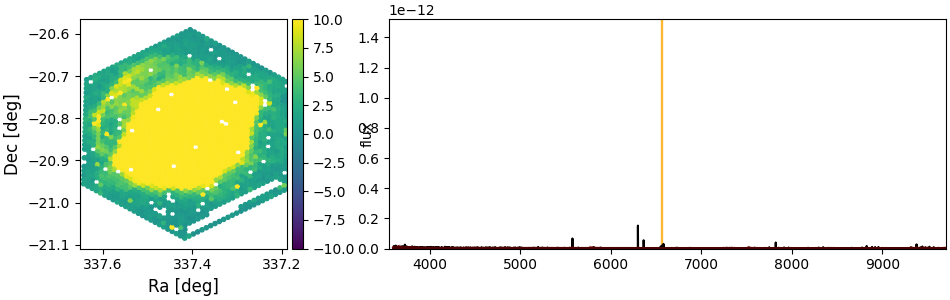

In [10]:
def add_fib(sel_fib,fib):
    sel_fib=np.append(sel_fib,fib)
    sel_fib=np.unique(sel_fib)
    return(sel_fib)
def spec_mean(data,sel_fib):
#    print(len(sel_fib))
    if (len(sel_fib)==1):
        spec=data[sel_fib,:]
        spec=spec.flatten()
    else:
        spec=np.mean(data[sel_fib,:],axis=0)
    return spec


global sp_y_min,sp_y_max,sp_x_min,sp_x_max,fib,cbar,cax0
global cmap,outfile,filetype
outfile='LVMsnap'
filetype='png'
cmap='viridis'
w0=6555
w1=6570
vmin=-10
vmax=10
#fib=int(len(tab_PT)/2)
fib=int(len(tab_PT)*0.3)
slice_img=get_slice_img(hdu['FLUX'].data,hdu['WAVE'].data,w0,w1)
tab_map=tab_PT
tab_map['flux']=slice_img
tab_map=tab_map[tab_map['mask']==1]

list_fib=[]
list_fib.append(fib)
c_fib='orange'
c_fib_now='grey'

dw=10*(hdu['WAVE'].data[1]-hdu['WAVE'].data[0])
fsize=3.5
gamma=1
sf=1
fig = plt.figure(figsize=(9.5, 3), layout="constrained")
fig.canvas.toolbar_visible = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.resizable = False

spec = fig.add_gridspec(1, 7, left=0.05, right=0.75,
                      hspace=0.1, wspace=0.4)
ax0 = fig.add_subplot(spec[0,0:2])
ax1 = fig.add_subplot(spec[0,2:7])


sc,ax_rec,cbar,cax0=map_plot(ax0,tab_map,line='flux', \
                 vmin=vmin, vmax=vmax, title=None, filename='junk',\
             cmap=cmap, fsize=fsize, figs_dir='figs')
m_fib=ax0.plot(tab_map['ra'][fib], tab_map['dec'][fib], \
               marker="o", markersize=5, markeredgecolor=c_fib, markerfacecolor="None")

sel_fib=[]
sel_fib.append(fib)
sel_fib=np.array(sel_fib)
sel_fib = add_fib(sel_fib,fib)
sel_m_fib=[]
sel_m_fib.append(m_fib)

m_spec=spec_mean(hdu['FLUX'].data,sel_fib)
e_m_spec=spec_mean(hdu['ERROR'].data,sel_fib)


sp_y_min=-0.5*np.nanmedian(hdu['FLUX'].data[fib,:])
sp_y_max=10*np.nanmax(hdu['FLUX'].data[fib,:])
sp_x_min=3550
sp_x_max=9700
sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)
mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)


def onclick(event):
    global sp_x_min,sp_x_max,w0,w1,ax0,ax1
    global vmin,vmax,sc,tab_map,sc,gamma,sf,cmap
    global mark,sp_y_min,sp_y_max,dw
            
    #
    # In AX1: Spec
    #
    if ((event.inaxes is ax1) & (event.xdata>ax1.get_xlim()[0]) & \
        (event.xdata<ax1.get_xlim()[1]) & \
        (event.ydata>ax1.get_ylim()[0]) & (event.ydata<ax1.get_ylim()[1])):
        if (event.button==1):
            w0=event.xdata
            if (w0>w1):
                w1=event.xdata+0.5*dw
        if (event.button==3):
            w1=event.xdata
            if (w0>w1):
                w0=event.xdata-0.5*dw
        dw=w1-w0
        try:
            mark.remove()
        except:
            mark_x=1
        mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
        slice_img=get_slice_img(hdu['FLUX'].data,hdu['WAVE'].data,w0,w1)
        tab_map['flux']=slice_img[tab_PT['mask']==1]                
        norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
        scat=scatter(tab_map['ra'], tab_map['dec'], ax0, size=sf*35.6/3600, \
                     c=tab_map['flux'], cmap=cmap, norm=norm)            
        sc_now=ax0.collections[0]
        sc_now.remove()
        w_range_widg.value[0]=np.round(w0,1)
        w_range_widg.value[1]=np.round(w1,1)

            

def moved_and_pressed(event):
    global sp_x_min,sp_x_max,fib,w0,w1,ax0,ax1
    global vmin,vmax,sc,tab_map,sc,gamma,sf,cmap
    global mark,sp_y_min,sp_y_max,m_fib
    global sel_fib,sel_m_fib
    global m_spec,e_m_spec
    
    print('button:',event.button)
    if (event.button==1):    
        #act_widg.value='Mouse-B1'
        #
        # In AX0: MAP
        #
        if ((event.inaxes is ax0) & (event.xdata>ax0.get_xlim()[1]) &\
            (event.xdata<ax0.get_xlim()[0]) & \
            (event.ydata>ax0.get_ylim()[0]) & (event.ydata<ax0.get_ylim()[1])):
            dist = np.sqrt((tab_map['ra']-event.xdata)**2+(tab_map['dec']-event.ydata)**2)
            fib_now = np.argmin(dist)
            sel_fib = add_fib(sel_fib,fib_now)
            #            m_fib.pop(0).remove()
            #mark.remove()
            m_fib_now=ax0.plot(tab_map['ra'][fib_now], tab_map['dec'][fib_now], \
               marker="o", markersize=5, markeredgecolor=c_fib_now, markerfacecolor="None")
            
            sel_m_fib.append(m_fib_now)
            [l.remove() for l in ax1.lines]
            m_spec=spec_mean(hdu['FLUX'].data,sel_fib)
            e_m_spec=spec_mean(hdu['ERROR'].data,sel_fib)
            sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                                  x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)
            #            mark.remove()
            #            mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
            
            act_widg.value=f'Fiber {fib_now} added'
            
    if (event.button==3):    
        #
        # In AX0: MAP
        #


        if ((event.inaxes is ax0) & (event.xdata>ax0.get_xlim()[1]) &\
            (event.xdata<ax0.get_xlim()[0]) & \
            (event.ydata>ax0.get_ylim()[0]) & (event.ydata<ax0.get_ylim()[1])):
            dist = np.sqrt((tab_map['ra']-event.xdata)**2+(tab_map['dec']-event.ydata)**2)
            fib_now = np.argmin(dist)
            sel_fib = np.delete(sel_fib, np.where(sel_fib == fib_now))
            for m_fib_now in sel_m_fib:
                try:
                    m_fib_now.pop(0).remove()
                except:
                    m_fib_now_x=1

            for fib_now in sel_fib:
                m_fib_now=ax0.plot(tab_map['ra'][fib_now], tab_map['dec'][fib_now], \
                                   marker="o", markersize=5, markeredgecolor=c_fib_now, markerfacecolor="None")
                sel_m_fib.append(m_fib_now)
            try:
                m_fib.pop(0).remove()
            except:
                m_fib_x=1
            m_fib=ax0.plot(tab_map['ra'][fib], tab_map['dec'][fib], \
                           marker="o", markersize=5, markeredgecolor=c_fib, markerfacecolor="None")
            [l.remove() for l in ax1.lines]
            m_spec=spec_mean(hdu['FLUX'].data,sel_fib)
            e_m_spec=spec_mean(hdu['ERROR'].data,sel_fib)
            sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                                  x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)
           
            act_widg.value=f'Fiber removed'

            
            
    if (event.button==2):
        #
        # In AX0: MAP
        #
        if ((event.inaxes is ax0) & (event.button==2) & (event.xdata>ax0.get_xlim()[1]) &\
            (event.xdata<ax0.get_xlim()[0]) & \
            (event.ydata>ax0.get_ylim()[0]) & (event.ydata<ax0.get_ylim()[1])):
            dist = np.sqrt((tab_map['ra']-event.xdata)**2+(tab_map['dec']-event.ydata)**2)
            fib = np.argmin(dist)
            try:
                m_fib.pop(0).remove()
            except:
                m_fib_x=1
            m_fib=ax0.plot(tab_map['ra'][fib], tab_map['dec'][fib], \
               marker="o", markersize=5, markeredgecolor=c_fib, markerfacecolor="None")
            [l.remove() for l in ax1.lines]
            m_spec=hdu['FLUX'].data[fib,:]
            e_m_spec=hdu['ERROR'].data[fib,:]            
            sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                                  x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)
            try:
                mark.remove()
            except:
                mark_x=1
            mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
            tx = '%d,%.1f,%.1f' % (fib,event.xdata, event.ydata)
            act_widg.value=f'Spectrum #{fib} shown'
            
        #
        # In AX1: Spec
        #
        if ((event.inaxes is ax1) & (event.button==2) & (event.xdata>ax1.get_xlim()[0]) & \
            (event.xdata<ax1.get_xlim()[1]) & \
            (event.ydata>ax1.get_ylim()[0]) & (event.ydata<ax1.get_ylim()[1])):
            w0=event.xdata-0.5*dw
            w1=event.xdata+0.5*dw
            try:
                mark.remove()
            except:
                mark_x
            mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
            slice_img=get_slice_img(hdu['FLUX'].data,hdu['WAVE'].data,w0,w1)
            tab_map['flux']=slice_img[tab_PT['mask']==1]                
            norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
            scat=scatter(tab_map['ra'], tab_map['dec'], ax0, size=sf*35.6/3600, \
                         c=tab_map['flux'], cmap=cmap, norm=norm)            
            sc_now=ax0.collections[0]
            sc_now.remove()
            w_range_widg.value[0]=np.round(w0,1)
            w_range_widg.value[1]=np.round(w1,1)
            #act_widg.value=f'1fib:{len(fib)}'
#            act_widg.value=f'Wavelength of the map: {w0}'
            

def w_update(change):
    global w0,w1
    w0=change.new[0]
    w1=change.new[1]
    map_update()

def w0_update(change):
    global w0
    w0=change.new
    map_update()
    
    
def cmap_update(change):
    global cmap
    cmap=change.new
    map_update()

def filetype_update(change):
    global filetype
    filetype=change.new
    
def outfile_update(change):
    global outfile,filetype
    outfile=change.new
    
def snap_save(change):
    global outfile,filetype
    plt.savefig(f'{outfile}.{filetype}', transparent=None, dpi='figure', format=None,
            metadata=None, bbox_inches=None, pad_inches=0.1,
            facecolor='auto', edgecolor='auto', backend=None)
    
    act_widg.value=f'{outfile}.{filetype} saved...'
    
def w1_update(change):
    global w1
    w1=change.new
    map_update()
    
def update_flux(change):
    global vmin,vmax
    vmin=change.new[0]
    vmax=change.new[1]
    map_update()
    
def map_update():
    global sp_x_min,sp_x_max,w0,w1,ax0,ax1
    global vmin,vmax,sc,tab_map,sc,gamma,sf,cmap
    global mark,cbar,cax0,scat
    global sp_y_min,sp_y_max,fib,mark
    global m_spec,e_m_spec
    [l.remove() for l in ax1.lines]
    sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)    
    mark.remove()
    mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
    slice_img=get_slice_img(hdu['FLUX'].data,hdu['WAVE'].data,w0,w1)
    tab_map['flux']=slice_img[tab_PT['mask']==1]                
    norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
    scat=scatter(tab_map['ra'], tab_map['dec'], ax0, size=sf*35.6/3600, \
                 c=tab_map['flux'], cmap=cmap, norm=norm)            
    sc_now=ax0.collections[0]
    sc_now.remove()
    cbar = plt.colorbar(scat.sc, cax=cax0)#,fontsize=21)
    w_range_widg.value=(np.round(w0,1),np.round(w1,1))
    
    
def update_spec_range(change):
    global sp_x_min,sp_x_max,sp_y_min,sp_y_max,fib,mark
    global m_spec,e_m_spec
    sp_x_min=change.new[0]
    sp_x_max=change.new[1]
    [l.remove() for l in ax1.lines]
    sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)
    #text.set_x(ax1.get_xlim()[0]+0.025*(ax1.get_xlim()[1]-ax1.get_xlim()[0]))
    #text.set_y(ax1.get_ylim()[1]-0.1*(ax1.get_ylim()[1]-ax1.get_ylim()[0]))
        
def update_spec_yrange(change):
    global sp_x_min,sp_x_max,sp_y_min,sp_y_max,fib,mark
    global m_spec,e_m_spec
    sp_y_min=change.new[0]/1e13
    sp_y_max=change.new[1]/1e13
    [l.remove() for l in ax1.lines]
    sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)
    #text.set_x(ax1.get_xlim()[0]+0.025*(ax1.get_xlim()[1]-ax1.get_xlim()[0]))
    #text.set_y(ax1.get_ylim()[1]-0.1*(ax1.get_ylim()[1]-ax1.get_ylim()[0]))    
    
    
int_range_xspec = widgets.FloatRangeSlider(
    value=(sp_x_min,sp_x_max), 
    min=sp_x_min, max=sp_x_max, step=hdu['WAVE'].data[1]-hdu['WAVE'].data[0], 
    description='Spec. Wave Range',layout=widgets.Layout(width='85%')
)

int_range_yspec = widgets.FloatRangeSlider(
    value=(-3*np.abs(sp_y_min)*1e13,3*np.abs(sp_y_max)*1e13), 
    min=-3*np.abs(sp_y_min)*1e13, max=3*np.abs(sp_y_max)*1e13, step=1e13*(sp_y_max-sp_y_min)/1000, 
    description='Spec. Flux Range',layout=widgets.Layout(width='85%')
)


int_range_flux = widgets.FloatRangeSlider(
    value=(vmin,vmax), 
    min=-2*np.abs(vmin), max=2500*vmax, step=(vmax-vmin)/100,
    description='Flux Range',layout=widgets.Layout(width='90%')
)

w_range_widg = widgets.FloatRangeSlider(
    value=(w0,w1), 
    min=sp_x_min, max=sp_x_max, step=hdu['WAVE'].data[1]-hdu['WAVE'].data[0], 
    description='Wave Map',layout=widgets.Layout(width='95%')
)


act_widg=widgets.Text(
    value='None',
    description='Action:',
    disabled=False,layout=widgets.Layout(width='60%')#,margin='0 0 0 0')
)


cmap_widg=widgets.Dropdown(
    options=plt.colormaps(),
    value=cmap,
    description='cmap:',
    disabled=False,layout=widgets.Layout(width='30%')
)

filetype_widg=widgets.Dropdown(
    options=['png','pdf'],
    value='png',
    description='type:',
    disabled=False,layout=widgets.Layout(width='30%')
)

outfile_widg=widgets.Text(
    value='LVMsnap',
    description='outfile:',
    disabled=False,layout=widgets.Layout(width='50%')#,margin='0 0 0 0')
)

snap_button = widgets.Button(description="Save File")

int_range_xspec.observe(update_spec_range, 'value')
int_range_yspec.observe(update_spec_yrange, 'value')
int_range_flux.observe(update_flux, 'value')
w_range_widg.observe(w_update, 'value')

cmap_widg.observe(cmap_update,'value')
filetype_widg.observe(filetype_update,'value')
outfile_widg.observe(outfile_update,'value')

snap_button.on_click(snap_save)

cid_click = fig.canvas.mpl_connect('button_press_event', onclick)
cid_hold = fig.canvas.mpl_connect('motion_notify_event', moved_and_pressed)


UBox = widgets.HBox([w_range_widg],
                    layout=widgets.Layout(width='100%', margin='0 0 0 0', align_items='stretch'))

LBox = widgets.VBox([int_range_xspec, int_range_yspec, act_widg],
                    layout=widgets.Layout(width='60%', margin='0 0 0 0'))

MBox = widgets.HBox([cmap_widg],
                    layout=widgets.Layout(width='100%', margin='0 0 0 0', align_items='stretch'))

DBox_buttons = widgets.HBox([outfile_widg, filetype_widg, snap_button])

RBox = widgets.VBox([int_range_flux, MBox, DBox_buttons],
                    layout=widgets.Layout(width='60%', margin='0 0 0 0', align_items='stretch'))

main_controls = widgets.HBox([RBox, LBox])
full_ui = widgets.VBox([fig.canvas, UBox, main_controls])

display(full_ui)


This cell finds the wavelength index nearest to 5650 Å, useful as a quick reference point when slicing the RSS.

## 8. Export a selected subset of fibers

This cell creates a new FITS structure containing only the currently selected fibers, preserving the key RSS-like extensions (`FLUX`, `IVAR`, `MASK`, `WAVE`, `LSF`, `SKY`, `SKY_IVAR`, and `SLITMAP`). This is useful when you want to save a small region or a hand-picked sample for later analysis.

In [12]:
hdu_sel = fits.PrimaryHDU(header=hdu[0].header)
hdu_list_sel = []
hdu_list_sel.append(hdu_sel)
names = ('FLUX','IVAR','MASK','WAVE','LSF','SKY','SKY_IVAR','SLITMAP')
for name in names:
    if ((name != 'WAVE') & (name != 'SLITMAP')):
        hdu_sel = fits.ImageHDU(data=hdu[name].data[sel_fib],\
                 header=hdu[name].header,name=name)
        hdu_list_sel.append(hdu_sel)
    else:
        if (name == 'WAVE'):
            hdu_sel = fits.ImageHDU(data=hdu[name].data,\
                                header=hdu[name].header,name=name)
            hdu_list_sel.append(hdu_sel)
        else:
            if (name == 'SLITMAP'):
                hdu_sel = fits.BinTableHDU(data=hdu[name].data[sel_fib],\
                                        header=hdu[name].header,name=name)
                hdu_list_sel.append(hdu_sel)
hdu_list = fits.HDUList(hdu_list_sel)
DIR_DRP = 'cache'
sky_file = f'{DIR_DRP}/sel-frame.fits'
hdu_list.writeto(sky_file,overwrite=True)



### About this notebook

This notebook was created to show how to open, and explore an LVM DRP SFrame product.

**Authors**: Sebastian F. Sanchez and the LVM team

**Last Update**: 2026 April 23

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.